In [1]:
import os
import shutil
from tqdm import tqdm

# Final Path Config
DATA_PATH = '/home/ma-user/work/sebabatso/raw/'
TARGET_PATH = '/home/ma-user/work/sebabatso/dataset_10'
CRUCIAL_LABELS = [
    "who",      # Subject / Question
    "doctor",   # Subject / Person
    "family",   # Subject / Person
    "go",       # Verb (Action)
    "help",     # Verb (Action)
    "finish",   # Verb (Completion)
    "work",     # Noun / Verb
    "computer", # Noun (Object)
    "book",     # Noun (Object)
    "yes"       # Modifier / Answer
]


def filter_dataset(split_name):
    for mode in ['frames', 'pose']:
        src_dir = os.path.join(DATA_PATH, 'asl_dataset/preprocessing', split_name, mode)
        dst_dir = os.path.join(TARGET_PATH, split_name, mode)
        
        if not os.path.exists(src_dir): 
            print(f"Skipping {split_name} {mode}: Source not found.")
            continue
            
        if not os.path.exists(dst_dir): 
            os.makedirs(dst_dir)

        print(f"Filtering {split_name} - {mode}...")
        
        # Get list of labels that actually exist in the source
        available_labels = os.listdir(src_dir)
        
        for label in tqdm(available_labels):
            if label.lower() in [l.lower() for l in CRUCIAL_LABELS]:
                s_path = os.path.join(src_dir, label)
                d_path = os.path.join(dst_dir, label)
                
                # Check if destination exists to avoid the TypeError
                if os.path.exists(d_path):
                    shutil.rmtree(d_path) # Clean up existing so we don't need dirs_exist_ok
                
                shutil.copytree(s_path, d_path)

for split in ['train', 'val', 'test']:
    filter_dataset(split)

print(f"✅ Subset created at: {TARGET_PATH}")

Filtering train - frames...


100%|██████████| 100/100 [00:00<00:00, 374.27it/s]


Filtering train - pose...


100%|██████████| 100/100 [00:00<00:00, 370.90it/s]


Filtering val - frames...


...

Filtering test - frames...


100%|██████████| 100/100 [00:00<00:00, 2040.39it/s]


Filtering test - pose...


100%|██████████| 100/100 [00:00<00:00, 2054.43it/s]

✅ Subset created at: /home/ma-user/work/sebabatso/dataset_10


In [2]:
import os
import numpy as np
import cv2
import mindspore as ms
import mindspore.nn as nn
from mindspore import ops, context, dataset as ds
from mindspore.ops import operations as P
from mindvision.classification.models import resnet34
from mindspore.train.callback import ModelCheckpoint, CheckpointConfig, LossMonitor, TimeMonitor

# # --- 1. CONFIGURATION ---
# context.set_context(mode=context.GRAPH_MODE, device_target="CPU")

# CRUCIAL_LABELS = [
#     "who",      # Subject / Question
#     "doctor",   # Subject / Person
#     "family",   # Subject / Person
#     "go",       # Verb (Action)
#     "help",     # Verb (Action)
#     "finish",   # Verb (Completion)
#     "work",     # Noun / Verb
#     "computer", # Noun (Object)
#     "book",     # Noun (Object)
#     "yes"       # Modifier / Answer
# ]

# mini_path = '/home/ma-user/work/sebabatso/dataset_mini'
save_dir = '/home/ma-user/work/sebabatso/models/'
if not os.path.exists(save_dir): os.makedirs(save_dir)

# --- 2. CUSTOM METRIC ---
class Top5Acc(nn.Metric):
    def __init__(self):
        super(Top5Acc, self).__init__()
        self.clear()
    def clear(self):
        self._correct, self._total = 0, 0
    def update(self, *inputs):
        y_pred = self._convert_data(inputs[0])
        y_true = self._convert_data(inputs[1])
        indices = np.argsort(y_pred, axis=1)[:, -5:]
        for i, label in enumerate(y_true):
            if label in indices[i]: self._correct += 1
            self._total += 1
    def eval(self):
        return self._correct / (self._total + 1e-6)

# --- 3. MODEL ARCHITECTURE ---
class ASL_DualStream_ResNet34(nn.Cell):
    def __init__(self, num_classes=10, hidden_dim=256):
        super(ASL_DualStream_ResNet34, self).__init__()
        base = resnet34(pretrained=True)
        self.backbone = base.backbone
        
        # Primitives for Graph Mode stability
        self.concat = P.Concat(axis=1)
        self.reshape = P.Reshape()
        self.reduce_mean = P.ReduceMean(keep_dims=False)
        
        # ResNet34 features = 512. Dual stream = 1024.
        self.gru = nn.GRU(input_size=1024, hidden_size=hidden_dim, num_layers=2, batch_first=True, dropout=0.5)
        self.classifier = nn.SequentialCell([
            nn.Dense(hidden_dim, 512),
            nn.ReLU(),
            nn.Dropout(keep_prob=0.6),
            nn.Dense(512, num_classes)
        ])

    def construct(self, rgb, pose):
        b, t, c, h, w = rgb.shape
        
        # 1. Process RGB Stream
        rgb_x = self.reshape(rgb, (b * t, c, h, w))
        rgb_feat = self.backbone(rgb_x)
        rgb_feat = self.reduce_mean(rgb_feat, (2, 3)) # Global Average Pooling
        
        # 2. Process Pose Stream
        pose_x = self.reshape(pose, (b * t, c, h, w))
        pose_feat = self.backbone(pose_x)
        pose_feat = self.reduce_mean(pose_feat, (2, 3)) # Global Average Pooling
        
        # 3. Concatenate and Temporal Modeling
        fused = self.concat((rgb_feat, pose_feat))
        fused = self.reshape(fused, (b, t, 1024))
        
        _, hidden = self.gru(fused)
        # hidden state of the last layer: (B, hidden_dim)
        return self.classifier(hidden[-1])

# --- 4. DATA GENERATOR ---
class ASLGenerator:
    def __init__(self, root, split, labels, training=True):
        self.f_root = os.path.join(root, split, 'frames')
        self.p_root = os.path.join(root, split, 'pose')
        self.training = training
        self.labels = sorted(labels)
        self.label_map = {name: i for i, name in enumerate(self.labels)}
        self.samples = []
        for l in self.labels:
            f_dir = os.path.join(self.f_root, l)
            if not os.path.exists(f_dir): continue
            for sid in os.listdir(f_dir):
                self.samples.append((os.path.join(f_dir, sid), os.path.join(self.p_root, l, sid), self.label_map[l]))

    def __getitem__(self, idx):
        f_p, p_p, lbl = self.samples[idx]
        return self._load(f_p), self._load(p_p), np.array(lbl, dtype=np.int32)

    def __len__(self): return len(self.samples)

    def _load(self, path):
        imgs = sorted([f for f in os.listdir(path) if f.endswith('.jpg')])[:16]
        flip = (np.random.rand() > 0.5) if self.training else False
        frames = []
        for f in imgs:
            img = cv2.imread(os.path.join(path, f))
            img = cv2.resize(img, (96, 96))
            if flip: img = cv2.flip(img, 1)
            frames.append(img.transpose(2, 0, 1) / 255.0)
        while len(frames) < 16: frames.append(np.zeros((3, 96, 96)))
        return np.array(frames, dtype=np.float32)

# --- 5. NETWORK WRAPPERS ---
class WithLossCell(nn.Cell):
    def __init__(self, backbone, loss_fn):
        super(WithLossCell, self).__init__(auto_prefix=False)
        self._backbone = backbone
        self._loss_fn = loss_fn
    def construct(self, rgb, pose, label):
        out = self._backbone(rgb, pose)
        return self._loss_fn(out, label)

class EvalNet(nn.Cell):
    def __init__(self, backbone):
        super(EvalNet, self).__init__(auto_prefix=False)
        self._backbone = backbone
    def construct(self, rgb, pose, label):
        out = self._backbone(rgb, pose)
        return out, label

# --- 6. EXECUTION PIPELINE ---

# Datasets
train_gen = ASLGenerator(TARGET_PATH, 'train', CRUCIAL_LABELS, training=True)
test_gen = ASLGenerator(TARGET_PATH, 'test', CRUCIAL_LABELS, training=False)
train_ds = ds.GeneratorDataset(train_gen, ["rgb", "pose", "label"],num_parallel_workers=4).batch(16)
test_ds = ds.GeneratorDataset(test_gen, ["rgb", "pose", "label"],num_parallel_workers=4).batch(16)

# Network initialization
net = ASL_DualStream_ResNet34(num_classes=len(CRUCIAL_LABELS))
loss_fn = nn.SoftmaxCrossEntropyWithLogits(sparse=True, reduction='mean')
optimizer = nn.Adam(net.trainable_params(), learning_rate=1e-4)

# Wrap for Graph stability
loss_net = WithLossCell(net, loss_fn)
eval_net = EvalNet(net)
train_net = nn.TrainOneStepCell(loss_net, optimizer)

model = ms.Model(network=train_net, eval_network=eval_net, metrics={'Top1': nn.Accuracy(), 'Top5': Top5Acc()})

steps_per_epoch = train_ds.get_dataset_size() 
print(f"Steps per epoch: {steps_per_epoch}")
# Callbacks
ckpoint_cb = ModelCheckpoint(prefix="asl_resnet34", directory=save_dir, 
                             config=CheckpointConfig(save_checkpoint_steps=steps_per_epoch, keep_checkpoint_max=3))

print("🚀 Starting Training (Fixed Primitives)...")
model.train(15, train_ds, callbacks=[LossMonitor(), TimeMonitor(), ckpoint_cb], dataset_sink_mode=False)

print("📊 Evaluating...")
res = model.eval(test_ds, dataset_sink_mode=False)
print(f"Final Result: {res}")

Steps per epoch: 11
🚀 Starting Training (Fixed Primitives)...
epoch: 1 step: 1, loss is 2.304882526397705
epoch: 1 step: 2, loss is 2.3093831539154053
epoch: 1 step: 3, loss is 2.3062691688537598
epoch: 1 step: 4, loss is 2.301938533782959
epoch: 1 step: 5, loss is 2.2981760501861572
epoch: 1 step: 6, loss is 2.304826259613037
epoch: 1 step: 7, loss is 2.302936553955078
epoch: 1 step: 8, loss is 2.2883262634277344
epoch: 1 step: 9, loss is 2.3051352500915527
epoch: 1 step: 10, loss is 2.303802490234375
epoch: 1 step: 11, loss is 2.2874438762664795
epoch time: 392552.921 ms, per step time: 35686.629 ms
epoch: 2 step: 1, loss is 2.289060354232788
epoch: 2 step: 2, loss is 2.2983951568603516
epoch: 2 step: 3, loss is 2.287637710571289
epoch: 2 step: 4, loss is 2.2807226181030273
epoch: 2 step: 5, loss is 2.2757105827331543
epoch: 2 step: 6, loss is 2.274317502975464
epoch: 2 step: 7, loss is 2.29409122467041
epoch: 2 step: 8, loss is 2.286010980606079
epoch: 2 step: 9, loss is 2.288392782

[WARNING] ME(1788:140257071683392,MainProcess):2026-03-22-16:45:47.332.76 [mindspore/dataset/engine/datasets_user_defined.py:756] GeneratorDataset's num_parallel_workers: 4 is too large which may cause a lot of memory occupation (>85%) or out of memory(OOM) during multiprocessing. Therefore, it is recommended to reduce num_parallel_workers to 1 or smaller.


📊 Evaluating...


[WARNING] ME(1788:140257071683392,MainProcess):2026-03-22-16:45:48.442.919 [mindspore/dataset/engine/datasets_user_defined.py:756] GeneratorDataset's num_parallel_workers: 4 is too large which may cause a lot of memory occupation (>85%) or out of memory(OOM) during multiprocessing. Therefore, it is recommended to reduce num_parallel_workers to 1 or smaller.
[WARNING] ME(1788:140257071683392,MainProcess):2026-03-22-16:45:48.839.265 [mindspore/dataset/engine/datasets_user_defined.py:756] GeneratorDataset's num_parallel_workers: 4 is too large which may cause a lot of memory occupation (>85%) or out of memory(OOM) during multiprocessing. Therefore, it is recommended to reduce num_parallel_workers to 1 or smaller.


Final Result: {'Top1': 0.25806451612903225, 'Top5': 0.7419354599375658}


[WARNING] ME(1788:140257071683392,MainProcess):2026-03-22-17:01:13.954.287 [mindspore/dataset/engine/datasets_user_defined.py:756] GeneratorDataset's num_parallel_workers: 4 is too large which may cause a lot of memory occupation (>85%) or out of memory(OOM) during multiprocessing. Therefore, it is recommended to reduce num_parallel_workers to 1 or smaller.


Gathering predictions...

--- Classification Report ---
              precision    recall  f1-score   support

         who       0.38      0.75      0.50         4
      doctor       0.14      0.20      0.17         5
      family       0.50      0.33      0.40         3
          go       0.00      0.00      0.00         2
        help       0.00      0.00      0.00         3
      finish       0.29      0.67      0.40         3
        work       0.00      0.00      0.00         3
    computer       0.00      0.00      0.00         3
        book       0.00      0.00      0.00         2
         yes       0.50      0.33      0.40         3

    accuracy                           0.26        31
   macro avg       0.18      0.23      0.19        31
weighted avg       0.20      0.26      0.21        31



/home/ma-user/anaconda3/envs/MindSpore/lib/python3.7/site-packages/sklearn/metrics/_classification.py:1272: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


<Figure size 1000x800 with 0 Axes>

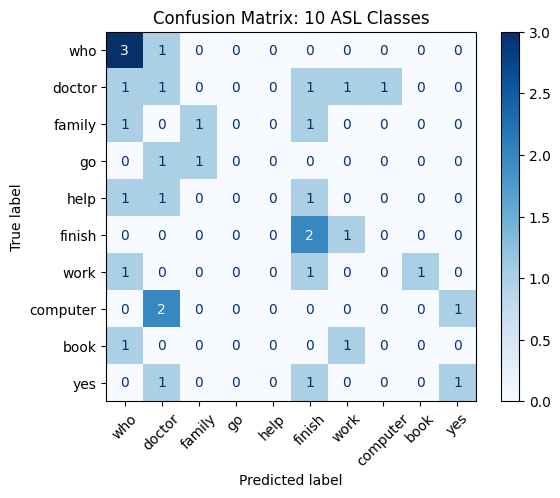

In [7]:

import mindspore as ms

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

def evaluate_model(network, test_ds, classes):
    print("Gathering predictions...")
    network.set_train(False) # Put the model in evaluation mode
    all_preds = []
    all_labels = []
    
    for data in test_ds.create_dict_iterator():
        # Get data
        rgb = data["rgb"]
        pose = data["pose"]
        label = data["label"].asnumpy()
        
        # 1. CALL THE RAW NET DIRECTLY (Fixes the TypeError)
        output = network(rgb, pose) 
        
        # 2. Process predictions
        preds = np.argmax(output.asnumpy(), axis=1)
        
        all_preds.extend(preds)
        all_labels.extend(label)

    # --- Metrics ---
    print("\n--- Classification Report ---")
    print(classification_report(all_labels, all_preds, target_names=classes))

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(cmap=plt.cm.Blues, values_format='d')
    plt.xticks(rotation=45)
    plt.title(f'Confusion Matrix: {len(classes)} ASL Classes')
    plt.show()

# Run it using 'net' instead of 'model'
evaluate_model(net, test_ds, CRUCIAL_LABELS)

In [4]:
import os
import shutil
import glob

# Find the newest .ckpt file
list_of_files = glob.glob(os.path.join(save_dir, "*.ckpt"))
if list_of_files:
    latest_ckpt = max(list_of_files, key=os.path.getctime)
    final_path = os.path.join(save_dir, "Sebabatso_ASL_Final.ckpt")
    shutil.copy2(latest_ckpt, final_path)
    print(f"⭐ Standard Checkpoint saved as: {final_path}")

⭐ Standard Checkpoint saved as: /home/ma-user/work/sebabatso/models/Sebabatso_ASL_Final.ckpt


In [5]:
import mindspore as ms
from mindspore import Tensor

# 1. Create dummy inputs to define the shape (16 frames, 3 channels, 96x96 resolution)
# We use batch size 1 for a single-person demo
dummy_rgb = Tensor(np.zeros([1, 16, 3, 96, 96]), ms.float32)
dummy_pose = Tensor(np.zeros([1, 16, 3, 96, 96]), ms.float32)

# 2. Export the file
file_name = os.path.join(save_dir, "Sebabatso_ASL_Model")
ms.export(net, dummy_rgb, dummy_pose, file_name=file_name, file_format='MINDIR')

print(f"🚀 Deployment Model exported to: {file_name}.mindir")

🚀 Deployment Model exported to: /home/ma-user/work/sebabatso/models/Sebabatso_ASL_Model.mindir


In [6]:
import moxing as mox

# 1. Local path: The entire project folder containing your notebooks and models
local_path = '/home/ma-user/work/sebabatso/'

# 2. OBS path: Your bucket and your specific folder
# This will recreate the 'sebabatso' folder structure in your asl-bucket
obs_path = 'obs://asl-bucket/sebabatso/'

# Synchronize everything (Notebooks, .py files, and the /models/ subfolder)
mox.file.copy_parallel(local_path, obs_path)

print(f"✅ Full Workspace Backup to {obs_path} completed!")

INFO:root:Using MoXing-v2.1.0.5d9c87c8-5d9c87c8
INFO:root:Using OBS-Python-SDK-3.20.9.1
/home/ma-user/anaconda3/envs/MindSpore/lib/python3.7/site-packages/requests/__init__.py:104: RequestsDependencyWarning: urllib3 (1.26.12) or chardet (5.2.0)/charset_normalizer (2.0.12) doesn't match a supported version!
  RequestsDependencyWarning)
INFO:root:1000/100226
INFO:root:2000/100226
INFO:root:3000/100226
INFO:root:4000/100226
INFO:root:5000/100226
INFO:root:6000/100226
INFO:root:7000/100226
INFO:root:8000/100226
INFO:root:9000/100226
INFO:root:10000/100226
INFO:root:11000/100226
INFO:root:12000/100226
INFO:root:13000/100226
INFO:root:14000/100226
INFO:root:15000/100226
INFO:root:16000/100226
INFO:root:17000/100226
INFO:root:18000/100226
INFO:root:19000/100226
INFO:root:20000/100226
INFO:root:21000/100226
INFO:root:22000/100226
INFO:root:23000/100226
INFO:root:24000/100226
INFO:root:25000/100226
INFO:root:26000/100226
INFO:root:27000/100226
INFO:root:28000/100226
INFO:root:29000/100226
INFO:

✅ Full Workspace Backup to obs://asl-bucket/sebabatso/ completed!
